### Getting the data

In [1]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-09-26 15:19:12--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8003::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  1.16MB/s    in 0.5s    

2026-09-26 15:19:13 (1.16 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

### Preparing the data

Use only the following columns:
- engine_displacement
- horsepower
- vehicle_weight
- model_year
- fuel_efficiency_mpg

In [3]:
data = pd.read_csv("car_fuel_efficiency_2026.csv")

In [4]:
data.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [5]:
data.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

No need to change/ format column names

In [6]:
data.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [7]:
data.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

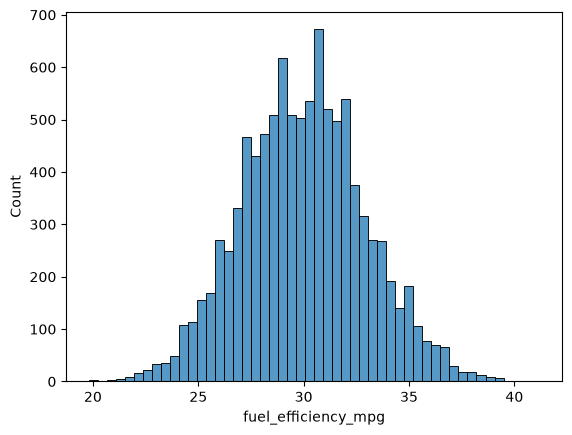

In [8]:
sns.histplot(data["fuel_efficiency_mpg"], bins=50)

Look at the fuel_efficiency_mpg variable. Does it have a long tail? `No`

In [9]:
columns = ["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]

In [10]:
for col in columns:
    print(col)
    print(data[col].nunique())
    print(data[col].unique()[:5])
    print()

engine_displacement
127
[2180 2390 2320 2130 2580]

horsepower
153
[243. 272. 267. 258. 304.]

vehicle_weight
176
[3870 4210 4240 4490 4510]

model_year
50
[2006 2008 1996 1989 1994]

fuel_efficiency_mpg
188
[31.9 31.3 27.5 28.5 31. ]



In [11]:
extracted_data = data[columns]
extracted_data.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### Q1. Missing value column

In [12]:
extracted_data.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Answer: `horsepower`

### Q2. What's the median (50% percentile) for variable 'horsepower'?

In [13]:
extracted_data.horsepower.median()

np.float64(254.0)

### Prepare and split the data

In [14]:
n = len(extracted_data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = extracted_data.iloc[idx[:n_train]]
df_val = extracted_data.iloc[idx[n_train:n_train + n_val]]
df_test = extracted_data.iloc[idx[n_train + n_val:]]

In [15]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [16]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [17]:
del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

### Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

In [18]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [19]:
def linear_regression(X, w0, w):
    return w0 + X.dot(w)

In [20]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return round(np.sqrt(mse),4)

In [21]:
base = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]

#### Fill with 0

In [22]:
def prepare_X(df):
    df = df[base]
    return df.fillna(0).values

In [23]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

In [24]:
X_val = prepare_X(df_val)
y_pred = linear_regression(X_val, w0, w)
rmse_0 = rmse(y_val, y_pred)

#### Fill with mean

In [25]:
mean = df_train.horsepower.mean()

In [26]:
def prepare_X_mean(df, mean):
    df = df[base]
    df["horsepower"] = df["horsepower"].fillna(mean)
    return df.values

In [27]:
X_train = prepare_X_mean(df_train, mean)
w0, w = train_linear_regression(X_train, y_train)

In [28]:
X_val = prepare_X(df_val)
y_pred = linear_regression(X_val, w0, w)
rmse_mean = rmse(y_val, y_pred)

In [29]:
print("With 0: ", rmse_0)
print("With mean: ", rmse_mean)

With 0:  2.2053
With mean:  2.2323


### Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?

If multiple options give the same best RMSE, select the smallest r.

In [30]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [31]:
for r in[0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r)

    X_val = prepare_X(df_val)
    y_pred = linear_regression(X_val, w0, w)
    score = rmse(y_val, y_pred)
    print(r, score)

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


### Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [32]:
n = len(extracted_data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

scores = []

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = extracted_data.iloc[idx[:n_train]]
    df_val = extracted_data.iloc[idx[n_train:n_train + n_val]]
    df_test = extracted_data.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train["fuel_efficiency_mpg"]
    del df_val["fuel_efficiency_mpg"]
    del df_test["fuel_efficiency_mpg"]

    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val)
    y_pred = linear_regression(X_val, w0, w)
    scores.append(rmse(y_val, y_pred))

round(np.std(scores),3)

np.float64(0.029)

### Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [33]:
n = len(extracted_data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = extracted_data.iloc[idx[:n_train]]
df_val = extracted_data.iloc[idx[n_train:n_train + n_val]]
df_test = extracted_data.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

df_full = pd.concat([df_train, df_val], ignore_index=True)
X_full = prepare_X(df_full)
y_full = np.concatenate((y_train, y_val))
w0, w = train_linear_regression(X_full, y_full)

X_test = prepare_X(df_test)
y_pred = linear_regression(X_test, w0, w)
round(rmse(y_test, y_pred), 3)

np.float64(2.236)